# TakeMeter — Fine-Tuning Starter Notebook
### AI201 · Project 3

This notebook walks you through fine-tuning a text classifier on your annotated dataset and comparing it to a zero-shot baseline.

**What this notebook does for you (infrastructure):**
- Tokenizes your dataset and prepares it for training
- Runs the fine-tuning pipeline with DistilBERT
- Computes evaluation metrics and generates a confusion matrix
- Runs the Groq baseline and compares both models

**What you do (the actual work):**
- Collect and annotate your 200+ examples (done before opening this notebook)
- Define your label map and upload your CSV
- Write your Groq classification prompt using your label definitions
- Analyze the output and write your evaluation report

---
**Before you start:** Make sure you are using a T4 GPU runtime.  
Go to **Runtime → Change runtime type → T4 GPU**, then click Save.

In [ ]:
# Install any dependencies not pre-installed on Colab
!pip install -q groq python-dotenv
print("✅ Dependencies ready")

✅ Dependencies ready


In [ ]:
import pandas as pd
import numpy as np
import json
import time

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay,
)
import matplotlib.pyplot as plt

import torch
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
    DataCollatorWithPadding,
)
from datasets import Dataset
import warnings
warnings.filterwarnings("ignore")

print("✅ Imports complete")
print(f"PyTorch version: {torch.__version__}")
print(f"GPU available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

✅ Imports complete
PyTorch version: 2.11.0+cu128
GPU available: True
GPU: Tesla T4


---
## Section 1: Load Your Dataset

Upload your labeled CSV and define your label map.  
Your CSV must have at least two columns: `text` (the post/comment) and `label` (your string label).

In [ ]:
# ── TODO ──────────────────────────────────────────────────────────────────
# Define YOUR label map below.
# Keys are the string labels in your CSV; values are integers starting at 0.
# Add or remove entries to match your actual labels (2–4 labels supported).
#
# The example below is ILLUSTRATIVE ONLY (the r/nba taxonomy from the project
# page). DELETE it and use your own community's labels — submitting the
# example unchanged will not pass.
# ────────────────────────────────────────────────────────────────────────

LABEL_MAP = {
    "analysis":  0,   # ← Replace with your first label
    "hot_take":  1,   # ← Replace with your second label
    "reaction":  2,   # ← Replace with your third label (remove if you have 2 labels)
    # "fourth_label": 3,  # ← Uncomment if you have a fourth label
}

# ── END TODO ──────────────────────────────────────────────────────────────

ID_TO_LABEL = {v: k for k, v in LABEL_MAP.items()}
NUM_LABELS = len(LABEL_MAP)
print(f"Labels: {LABEL_MAP}")
print(f"Number of labels: {NUM_LABELS}")

Labels: {'analysis': 0, 'hot_take': 1, 'reaction': 2}
Number of labels: 3


In [ ]:
# Upload your CSV from your computer
from google.colab import files
print("Select your labeled dataset CSV file...")
uploaded = files.upload()
CSV_PATH = list(uploaded.keys())[0]
print(f"Uploaded: {CSV_PATH}")

Select your labeled dataset CSV file...


Saving dataset.csv to dataset (1).csv
Uploaded: dataset (1).csv


In [ ]:
# Load and validate your dataset
df = pd.read_csv(CSV_PATH)

# ── TODO (if needed) ──────────────────────────────────────────────────────
# If your CSV uses different column names, rename them here.
# Example: df = df.rename(columns={"post": "text", "category": "label"})
# ── END TODO ──────────────────────────────────────────────────────────────

print(f"Columns: {df.columns.tolist()}")
print(f"Total examples: {len(df)}")
print()
print("Label distribution:")
print(df["label"].value_counts())

# Validate all labels are in LABEL_MAP
unknown = set(df["label"].unique()) - set(LABEL_MAP.keys())
if unknown:
    print(f"\n⚠️  Labels in CSV not found in LABEL_MAP: {unknown}")
    print("Update your LABEL_MAP above to include all labels.")
else:
    print("\n✅ All labels match your LABEL_MAP")

# Convert string labels to integers
df["label_id"] = df["label"].map(LABEL_MAP)
df = df.dropna(subset=["label_id"])
df["label_id"] = df["label_id"].astype(int)

Columns: ['text', 'label', 'notes']
Total examples: 218

Label distribution:
label
analysis    106
hot_take     60
reaction     52
Name: count, dtype: int64

✅ All labels match your LABEL_MAP


---
## Section 2: Prepare Data for Training

Splits your dataset into train / validation / test sets and tokenizes the text.

In [ ]:
# Train / val / test split — 70% / 15% / 15%
# Stratified so each split has roughly the same label distribution.
train_df, temp_df = train_test_split(
    df, test_size=0.30, random_state=42, stratify=df["label_id"]
)
val_df, test_df = train_test_split(
    temp_df, test_size=0.50, random_state=42, stratify=temp_df["label_id"]
)

print(f"Train: {len(train_df)} examples")
print(f"Validation: {len(val_df)} examples")
print(f"Test: {len(test_df)} examples")
print()
print("Train label distribution:")
print(train_df["label"].value_counts())
print()
print("Test label distribution:")
print(test_df["label"].value_counts())

# Reset indices (needed for clean HuggingFace Dataset conversion)
train_df = train_df.reset_index(drop=True)
val_df   = val_df.reset_index(drop=True)
test_df  = test_df.reset_index(drop=True)

Train: 152 examples
Validation: 33 examples
Test: 33 examples

Train label distribution:
label
analysis    74
hot_take    42
reaction    36
Name: count, dtype: int64

Test label distribution:
label
analysis    16
hot_take     9
reaction     8
Name: count, dtype: int64


In [ ]:
# Load tokenizer and tokenize all splits
MODEL_NAME = "distilbert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

def tokenize(examples):
    return tokenizer(examples["text"], truncation=True, max_length=256)

def make_dataset(df_split):
    ds = Dataset.from_pandas(
        df_split[["text", "label_id"]].rename(columns={"label_id": "labels"})
    )
    return ds.map(tokenize, batched=True)

train_dataset = make_dataset(train_df)
val_dataset   = make_dataset(val_df)
test_dataset  = make_dataset(test_df)

data_collator = DataCollatorWithPadding(tokenizer=tokenizer)
print("✅ Tokenization complete")
print(f"Sample keys: {list(train_dataset[0].keys())}")

Map:   0%|          | 0/152 [00:00<?, ? examples/s]

Map:   0%|          | 0/33 [00:00<?, ? examples/s]

Map:   0%|          | 0/33 [00:00<?, ? examples/s]

✅ Tokenization complete
Sample keys: ['text', 'labels', 'input_ids', 'token_type_ids', 'attention_mask']


---
## Section 3: Fine-Tune Your Model

Loads `distilbert-base-uncased` with a classification head and fine-tunes it on your training data.  
Training runs for 3 epochs and takes **5–15 minutes** on a T4 GPU.

> **Hyperparameter note:** The defaults below work well for datasets of 100–500 examples.  
> If you change any values, note what you changed and why in your README.

In [ ]:
# Load DistilBERT with a classification head
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=NUM_LABELS,
    id2label=ID_TO_LABEL,
    label2id=LABEL_MAP,
)
print(f"✅ Model loaded: {MODEL_NAME}")
print(f"Output labels: {NUM_LABELS}")

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
classifier.weight       | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


✅ Model loaded: distilbert-base-uncased
Output labels: 3


In [ ]:
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)
    return {"accuracy": accuracy_score(labels, predictions)}

In [ ]:
# ── Hyperparameters ───────────────────────────────────────────────────────
# num_train_epochs  — passes through the training data; 3 is a good default
#                     for small datasets. Increase cautiously; more epochs
#                     risk overfitting on 200 examples.
# learning_rate     — 2e-5 is the standard starting point for fine-tuning
#                     BERT-family models. Lower → slower but more stable.
# per_device_train_batch_size — 16 fits T4 GPU comfortably.
#                     Reduce to 8 if you get out-of-memory errors.
# ─────────────────────────────────────────────────────────────────────────
training_args = TrainingArguments(
    output_dir="./takemeter-model",
    num_train_epochs=10,              # was 3 — gives ~200 gradient steps
    per_device_train_batch_size=8,    # was 16 — doubles steps/epoch to ~20
    per_device_eval_batch_size=32,
    learning_rate=2e-5,
    weight_decay=0.01,
    warmup_steps=20,                  # ~10% of ~200 total steps — sensible proportion
    eval_strategy="epoch",
    save_strategy="epoch",
    save_total_limit=1,
    load_best_model_at_end=True,
    metric_for_best_model="accuracy",
    logging_steps=10,
    report_to="none",
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
)

print("Starting fine-tuning... (5–15 minutes on T4 GPU)")
trainer.train()
print("\n✅ Fine-tuning complete")

Starting fine-tuning... (5–15 minutes on T4 GPU)


Epoch,Training Loss,Validation Loss,Accuracy
1,1.077895,1.026451,0.484848
2,0.972783,0.955979,0.484848
3,0.890160,0.837082,0.575758
4,0.604816,0.669189,0.757576
5,0.416517,0.564742,0.787879
6,0.282488,0.456015,0.757576
7,0.129754,0.453009,0.757576
8,0.097964,0.438674,0.757576
9,0.067554,0.447063,0.757576
10,0.060502,0.456275,0.757576


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


✅ Fine-tuning complete


---
## Section 4: Evaluate Fine-Tuned Model on Test Set

Runs inference on your locked test set and generates metrics and a confusion matrix.  
These numbers go directly into your evaluation report.

In [ ]:
# Run inference on the test set
print("Running inference on test set...")
ft_output = trainer.predict(test_dataset)
ft_pred_ids = np.argmax(ft_output.predictions, axis=-1)
ft_true_ids = ft_output.label_ids

ft_probs = torch.nn.functional.softmax(
    torch.tensor(ft_output.predictions), dim=-1
).numpy()

# Overall accuracy
ft_accuracy = accuracy_score(ft_true_ids, ft_pred_ids)
print(f"\n🎯 Fine-tuned model accuracy: {ft_accuracy:.3f}")

# Per-class metrics
label_names = [ID_TO_LABEL[i] for i in range(NUM_LABELS)]
print("\nPer-class metrics (fine-tuned model):")
print(classification_report(ft_true_ids, ft_pred_ids, target_names=label_names, zero_division=0))

Running inference on test set...



🎯 Fine-tuned model accuracy: 0.758

Per-class metrics (fine-tuned model):
              precision    recall  f1-score   support

    analysis       0.73      1.00      0.84        16
    hot_take       0.78      0.78      0.78         9
    reaction       1.00      0.25      0.40         8

    accuracy                           0.76        33
   macro avg       0.84      0.68      0.67        33
weighted avg       0.81      0.76      0.72        33



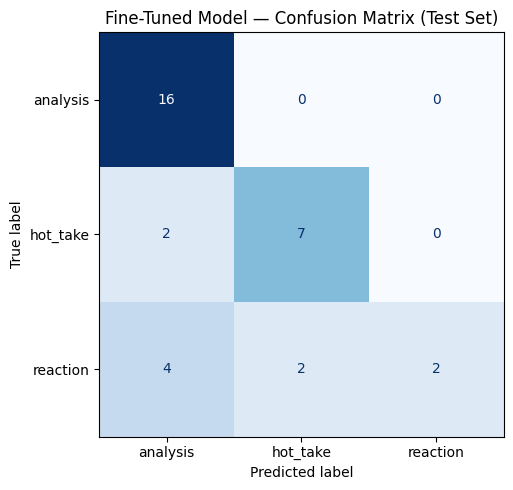

✅ Saved: confusion_matrix.png  →  commit this to your repo and include in README


In [ ]:
# Confusion matrix
cm = confusion_matrix(ft_true_ids, ft_pred_ids)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=label_names)
fig, ax = plt.subplots(figsize=(7, 5))
disp.plot(ax=ax, cmap="Blues", colorbar=False)
ax.set_title("Fine-Tuned Model — Confusion Matrix (Test Set)")
plt.tight_layout()
plt.savefig("confusion_matrix.png", dpi=150)
plt.show()
print("✅ Saved: confusion_matrix.png  →  commit this to your repo and include in README")

In [ ]:
# Print wrong predictions for your error analysis
# Review these carefully — pick 3 to analyze in depth in your README.

wrong_idx = np.where(ft_pred_ids != ft_true_ids)[0]
print(f"Wrong predictions: {len(wrong_idx)} / {len(ft_true_ids)}\n")

for i, idx in enumerate(wrong_idx[:15]):
    text = test_df.iloc[idx]["text"]
    true_label = ID_TO_LABEL[ft_true_ids[idx]]
    pred_label = ID_TO_LABEL[ft_pred_ids[idx]]
    confidence = ft_probs[idx][ft_pred_ids[idx]]
    print(f"--- #{i+1} ---")
    print(f"Text:      {text[:200]}{'...' if len(text) > 200 else ''}")
    print(f"True:      {true_label}")
    print(f"Predicted: {pred_label}  (confidence: {confidence:.2f})")
    print()

Wrong predictions: 8 / 33

--- #1 ---
Text:      Agree on the mediums and yes the McLarens are clearly the better cars. That was just top-tier racecraft from Verstappen establishing his lead aggressively from the start doing what he does best.
True:      reaction
Predicted: hot_take  (confidence: 0.48)

--- #2 ---
Text:      No one's saying Albon was in a Williams then. The point is that Albon has been crashed out preventing his first race win and he was resilient enough to get over that. You can see in his post-race inte...
True:      hot_take
Predicted: analysis  (confidence: 0.67)

--- #3 ---
Text:      i can't believe how entertaining the race actually was compared to previous years.. the softer tyres added strategy options and SC in the last ten laps was fun.. Max's move was awesome i didn't even s...
True:      reaction
Predicted: analysis  (confidence: 0.89)

--- #4 ---
Text:      Hadjar beating Leclerc in the midfield battle after the safety car on lap 53 was one of those momen

---
## Section 5: Baseline Classifier (Groq)

Runs your zero-shot baseline using `llama-3.3-70b-versatile`.  
You need to write the classification prompt using your label definitions.

In [ ]:
from groq import Groq

# ── TODO: Add your Groq API key ───────────────────────────────────────────
# Recommended: use Colab Secrets so your key is never visible in the notebook.
#   1. Click the 🔑 icon in the left sidebar ("Secrets")
#   2. Add a secret named GROQ_API_KEY with your key as the value
#   3. Enable notebook access for the secret
#
# Then uncomment Option A below (and delete Option B).
#
# Option A — Colab Secrets (recommended):
from google.colab import userdata
GROQ_API_KEY = userdata.get("GROQ_API_KEY")
#
# Option B — paste directly (do not commit to GitHub):
#GROQ_API_KEY = "your_groq_api_key_here"

assert GROQ_API_KEY, (
    "GROQ_API_KEY not set — add it in the Colab Secrets panel (\U0001f511, left "
    "sidebar) and enable notebook access for this notebook, or use Option B above."
)

client = Groq(api_key=GROQ_API_KEY)
print("✅ Groq client initialized")

✅ Groq client initialized


In [ ]:
# ── TODO: Write your classification prompt ────────────────────────────────
# Your prompt should:
#   1. Name your community and task
#   2. Define each label in plain language (copy from your planning.md)
#   3. Give one example post per label
#   4. Tell the model to output ONLY the label name — nothing else
#
# The model's response must match one of your label strings exactly,
# or the classify_with_groq() function below will mark it as unparseable.
#
# ─────────────────────────────────────────────────────────────────────────
# REPLACE the placeholders below with your actual prompt. As written, this
# skeleton will NOT classify correctly — you must fill it in.

SYSTEM_PROMPT = """
You are classifying comments from r/formula1, a Formula 1 discussion community.

Assign each comment to exactly one of the following labels:

analysis: The comment constructs a structured argument using specific, verifiable F1 evidence — lap times, tire strategy windows, sector splits, championship math, car specs, or historical comparisons with named statistics. The evidence is load-bearing: remove it and the argument collapses.
Example: "Was it really a bad strategy though? He came out ahead of Alonso, and Williams has run this one-stop window so many times — the SC was luck, not a bad call."

hot_take: A bold, confident opinion about a driver, team, regulation, or era stated without meaningful supporting evidence. A stat may appear but is decorative — used to sound credible rather than to genuinely reason. The framing is assertive rather than analytical.
Example: "Hamilton was only good because of the Mercedes. Seven titles mean nothing if the car does the work."

reaction: An immediate emotional or expressive response to a specific, identifiable F1 event — a crash, overtake, penalty, qualifying lap, result, or announcement. The comment expresses a feeling in the moment rather than arguing a position.
Example: "I cannot believe what Lando just did. That overtake was absolutely insane, I'm shaking."

Respond with ONLY the label name — one word or phrase, nothing else.
Do not explain your reasoning. Do not add punctuation.

Valid labels:
analysis
hot_take
reaction
"""

print("Prompt length:", len(SYSTEM_PROMPT), "characters")

Prompt length: 1491 characters


In [ ]:
def classify_with_groq(text):
    """Classify a single post. Returns a label string or None if unparseable."""
    try:
        response = client.chat.completions.create(
            model="llama-3.3-70b-versatile",
            messages=[
                {"role": "system", "content": SYSTEM_PROMPT},
                {"role": "user", "content": f"Classify this post:\n\n{text}"},
            ],
            temperature=0,
            max_tokens=20,
        )
        raw = response.choices[0].message.content.strip().lower()
        # Match the model's output to a label. Check longest labels first so a
        # label that is a substring of another (e.g. "recommendation" vs.
        # "strong_recommendation") can't be matched by mistake.
        for label in sorted(LABEL_MAP, key=len, reverse=True):
            if raw == label or label in raw:
                return label
        return None  # model output didn't match any known label
    except Exception as e:
        print(f"API error: {e}")
        return None


# Run baseline on test set
print(f"Running baseline on {len(test_df)} examples...")
print("(May take a few minutes — 0.1s delay between requests to respect free-tier limits)\n")

baseline_preds = []
for i, (_, row) in enumerate(test_df.iterrows()):
    pred = classify_with_groq(row["text"])
    baseline_preds.append(pred)
    if (i + 1) % 10 == 0:
        print(f"  {i+1}/{len(test_df)} complete...")
    time.sleep(0.1)

none_count = baseline_preds.count(None)
if none_count > 0:
    print(f"\n⚠️  {none_count} responses could not be parsed.")
    print("Review your prompt — the model may not be outputting clean label names.")

Running baseline on 33 examples...
(May take a few minutes — 0.1s delay between requests to respect free-tier limits)

  10/33 complete...
  20/33 complete...
  30/33 complete...


In [ ]:
# Baseline metrics (exclude unparseable responses)
valid = [(p, t) for p, t in zip(baseline_preds, test_df["label_id"])
         if p is not None]
bl_pred_ids = [LABEL_MAP[p] for p, _ in valid]
bl_true_ids = [t for _, t in valid]

bl_accuracy = accuracy_score(bl_true_ids, bl_pred_ids)
print(f"🎯 Baseline accuracy: {bl_accuracy:.3f}  "
      f"(evaluated on {len(valid)}/{len(test_df)} parseable responses)")
print()
label_names = [ID_TO_LABEL[i] for i in range(NUM_LABELS)]
print("Per-class metrics (baseline):")
print(classification_report(bl_true_ids, bl_pred_ids, target_names=label_names, zero_division=0))

🎯 Baseline accuracy: 0.848  (evaluated on 33/33 parseable responses)

Per-class metrics (baseline):
              precision    recall  f1-score   support

    analysis       0.84      1.00      0.91        16
    hot_take       1.00      0.67      0.80         9
    reaction       0.75      0.75      0.75         8

    accuracy                           0.85        33
   macro avg       0.86      0.81      0.82        33
weighted avg       0.86      0.85      0.84        33



---
## Section 6: Compare Results and Export

Side-by-side comparison of both models.  
Download the output files and commit them to your GitHub repo.

In [ ]:
print("=" * 50)
print("RESULTS COMPARISON")
print("=" * 50)
print(f"{'Model':<35} {'Accuracy':>8}")
print("-" * 45)
print(f"{'Zero-shot baseline (Groq)':<35} {bl_accuracy:>8.3f}")
print(f"{'Fine-tuned DistilBERT':<35} {ft_accuracy:>8.3f}")
print("-" * 45)
delta = ft_accuracy - bl_accuracy
direction = "improvement" if delta >= 0 else "regression"
print(f"\nFine-tuning {direction}: {abs(delta):.3f}")
print()
print("Use these numbers in your README evaluation report.")

RESULTS COMPARISON
Model                               Accuracy
---------------------------------------------
Zero-shot baseline (Groq)              0.848
Fine-tuned DistilBERT                  0.758
---------------------------------------------

Fine-tuning regression: 0.091

Use these numbers in your README evaluation report.


In [ ]:
# Save results JSON — commit to your GitHub repo and reference in README
results = {
    "baseline_accuracy": round(bl_accuracy, 4),
    "finetuned_accuracy": round(ft_accuracy, 4),
    "improvement": round(ft_accuracy - bl_accuracy, 4),
    "test_set_size": len(test_df),
    "label_map": LABEL_MAP,
    "model": MODEL_NAME,
}
with open("evaluation_results.json", "w") as f:
    json.dump(results, f, indent=2)

print("✅ Files ready to download:")
print("   evaluation_results.json  — metrics for your README")
print("   confusion_matrix.png     — include in your README")
print()
print("Download via: Files panel (📁) on the left → right-click → Download")

✅ Files ready to download:
   evaluation_results.json  — metrics for your README
   confusion_matrix.png     — include in your README

Download via: Files panel (📁) on the left → right-click → Download


In [ ]:
def classify(text):
    inputs = tokenizer(text, return_tensors="pt", truncation=True, max_length=256)
    inputs = {k: v.to(model.device) for k, v in inputs.items()}  # ← add this line
    with torch.no_grad():
        logits = model(**inputs).logits
    probs = F.softmax(logits, dim=-1)[0]
    pred_id = probs.argmax().item()
    print(f"Label:      {ID_TO_LABEL[pred_id]}")
    print(f"Confidence: {probs[pred_id]:.2f}")
    for i, name in ID_TO_LABEL.items():
        print(f"  {name}: {probs[i]:.2f}")

In [ ]:
classify("They don't have the same equipment though. Yuki had already lost the new spec wing \
because they took it off his car to put on Max's on Saturday. That's not to say he'd be near \
Max, but let's get the facts straight.")

Label:      analysis
Confidence: 0.55
  analysis: 0.55
  hot_take: 0.36
  reaction: 0.09


In [ ]:
classify("Max is the best driver since Schumi. Lewis never had to struggle with his car. The moment the car was not the fastest on the grid he lost all chances of a WDC.")

Label:      hot_take
Confidence: 0.56
  analysis: 0.25
  hot_take: 0.56
  reaction: 0.19


In [ ]:
classify("Hamilton was only good because of the Mercedes. Ferrari is exposing exactly how \
average he always was. Seven titles mean nothing if the car is doing the work.")

Label:      analysis
Confidence: 0.50
  analysis: 0.50
  hot_take: 0.33
  reaction: 0.17


In [ ]:
classify("i can't believe how entertaining the race actually was compared to previous years.. \
the softer tyres added strategy options and SC in the last ten laps was fun.. \
Max's move was awesome i didn't even see it coming until he already almost passed oscar.")

Label:      analysis
Confidence: 0.86
  analysis: 0.86
  hot_take: 0.05
  reaction: 0.09
